In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from lazy5.inspect import get_attrs_dset
import os
from crikit.preprocess.denoise import SVDDecompose, SVDRecompose
from crikit.cri.kk import KramersKronig
from crikit.cri.error_correction import PhaseErrCorrectALS


In [2]:
loaded = np.load('denoise/denoised_test_data.npz')

In [3]:
raw = loaded['raw']
_denoised = loaded['denoised']
denoised=_denoised.transpose(1,2,0)
wn = loaded['wn']

In [4]:
signature_index = 527
point_signal = [20, 20]  # Example point (y, x)
point_noise = [165, 20]  # Example point (y, x)s

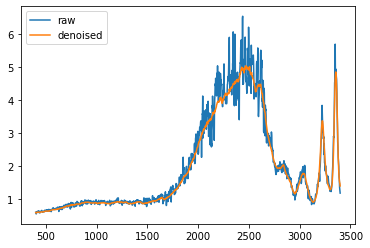

In [5]:
%matplotlib inline
plt.plot(wn, raw[100,100,:], label='raw')
plt.plot(wn, denoised[100,100,:], label='denoised')
plt.legend()

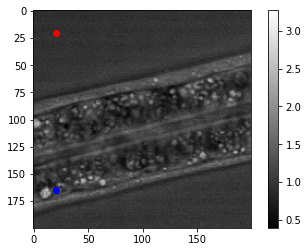

In [6]:

plt.imshow(raw[:,:,signature_index], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro')  # Note the order (x, y)
plt.plot(point_noise[1], point_noise[0], 'bo')  # Note the
plt.colorbar()

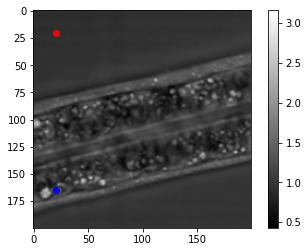

In [7]:

plt.imshow(denoised[:,:,signature_index], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro')  # Note the order (x, y)
plt.plot(point_noise[1], point_noise[0], 'bo')  # Note the order (x, y)
plt.colorbar()

No handles with labels found to put in legend.


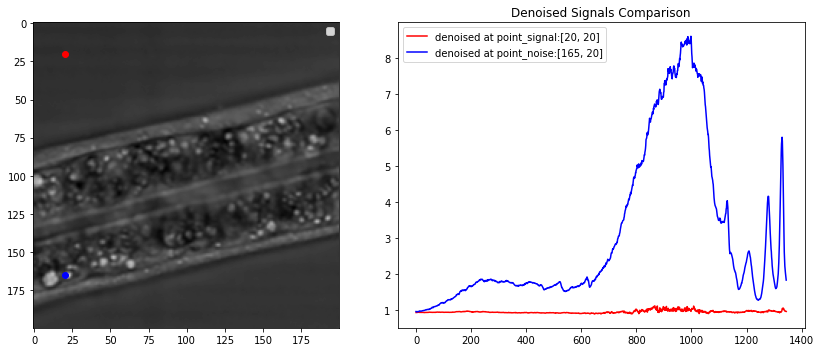

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot - your existing content (you can customize this)
ax1.imshow(denoised[:,:,signature_index], cmap='gray')
ax1.plot(point_signal[1], point_signal[0], 'ro')  # Note the order (x, y)
ax1.plot(point_noise[1], point_noise[0], 'bo')  # Note the order (x, y)
ax1.legend()


# Right plot - the denoised signals comparison
ax2.plot(denoised[point_signal[0],point_signal[1],:],color='r',label=f'denoised at point_signal:{point_signal}')
ax2.plot(denoised[point_noise[0],point_noise[1],:],color='b',label=f'denoised at point_noise:{point_noise}')
ax2.set_title('Denoised Signals Comparison')
ax2.legend()

plt.tight_layout()
plt.show()

No handles with labels found to put in legend.


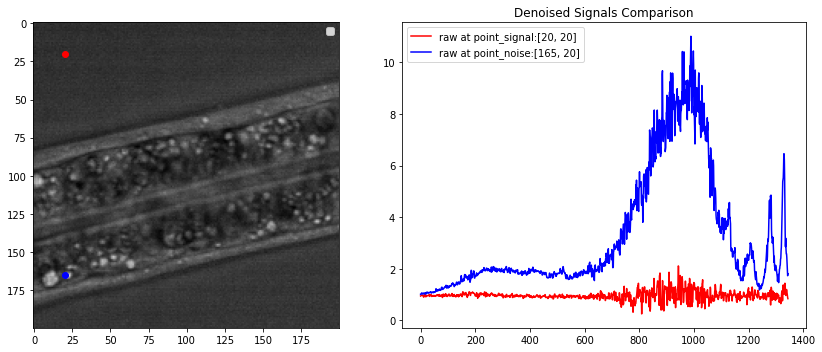

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot - your existing content (you can customize this)
ax1.imshow(raw[:,:,signature_index], cmap='gray')
ax1.plot(point_signal[1], point_signal[0], 'ro')  # Note the order (x, y)
ax1.plot(point_noise[1], point_noise[0], 'bo')  # Note the order (x, y)
ax1.legend()


# Right plot - the denoised signals comparison
ax2.plot(raw[point_signal[0],point_signal[1],:],color='r',label=f'raw at point_signal:{point_signal}')
ax2.plot(raw[point_noise[0],point_noise[1],:],color='b',label=f'raw at point_noise:{point_noise}')
ax2.set_title('Denoised Signals Comparison')
ax2.legend()

plt.tight_layout()
plt.savefig('')
plt.show()

In [10]:
ratio_selected= raw
svd_decompose = SVDDecompose()
# Load the HDF5 dataset into a NumPy array
U,s,Vh = svd_decompose.calculate(ratio_selected)

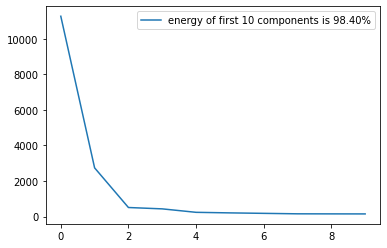

In [11]:
svs = np.arange(10)  # Select singular values 0 to 10
plt.plot(s[svs],label='energy of first {} components is {:.2f}'.format(len(svs),np.sum(s[svs]**2)/np.sum(s**2)*100)+'%')
plt.legend()

In [12]:

# Only keep selected singular values and corresponding vectors
U_sel = U[:, svs]
s_sel = s[svs]
Vh_sel = Vh[svs, :]

# Multiply each row of Vh_sel by the corresponding singular value
reconstructed = np.dot(U_sel, s_sel[:, None] * Vh_sel)
reconstructed_reshaped = reconstructed.reshape(ratio_selected.shape)

No handles with labels found to put in legend.


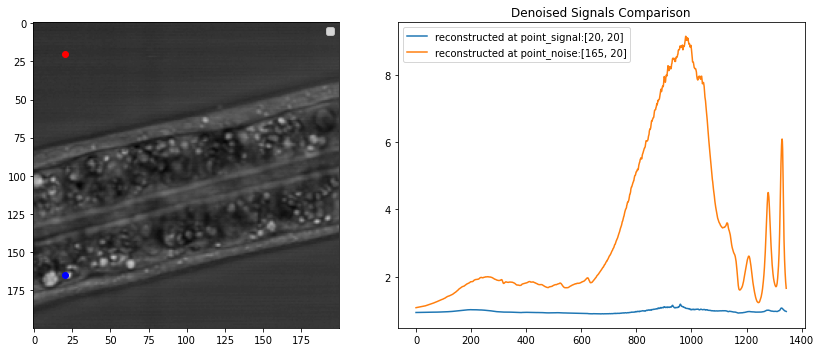

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot - your existing content (you can customize this)
ax1.imshow(reconstructed_reshaped[:,:,signature_index], cmap='gray')
ax1.plot(point_signal[1], point_signal[0], 'ro')  # Note the order (x, y)
ax1.plot(point_noise[1], point_noise[0], 'bo')  # Note the order (x, y)
ax1.legend()


# Right plot - the denoised signals comparison
ax2.plot(reconstructed_reshaped[point_signal[0],point_signal[1],:],label=f'reconstructed at point_signal:{point_signal}')
ax2.plot(reconstructed_reshaped[point_noise[0],point_noise[1],:],label=f'reconstructed at point_noise:{point_noise}')
ax2.set_title('Denoised Signals Comparison')
ax2.legend()

plt.tight_layout()
plt.show()

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


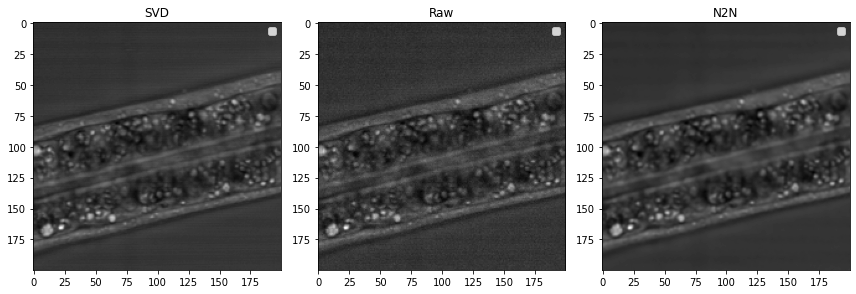

In [14]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(12, 5))

# Left plot - your existing content (you can customize this)
ax1.imshow(reconstructed_reshaped[:,:,signature_index], cmap='gray')
#ax1.plot(point_signal[1], point_signal[0], 'ro')  # Note the order (x, y)
#ax1.plot(point_noise[1], point_noise[0], 'bo')  # Note the order (x, y)
ax1.legend()
ax1.set_title('SVD')
# Middle plot - the denoised signals comparison
ax2.imshow(raw[:,:,signature_index], cmap='gray')
#ax2.plot(point_signal[1], point_signal[0], 'ro')  # Note the order (x, y)
#ax2.plot(point_noise[1], point_noise[0], 'bo')  # Note the order (x, y)
ax2.legend()
ax2.set_title('Raw')
# Right plot - the denoised signals comparison
ax3.imshow(denoised[:,:,signature_index], cmap='gray')
#ax3.plot(point_signal[1], point_signal[0], 'ro')  # Note the order (x, y)
#ax3.plot(point_noise[1], point_noise[0], 'bo')  # Note the order (x, y)
ax3.legend()
ax3.set_title('N2N')
plt.tight_layout()
#plt.colorbar()
plt.show()

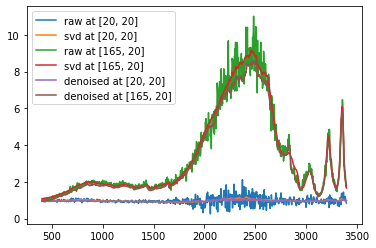

In [ ]:
plt.plot(wn,ratio_selected[point_signal[0],point_signal[1],:], label=f'raw at {point_signal}')
plt.plot(wn, reconstructed_reshaped[point_signal[0],point_signal[1],:],label =f'svd at {point_signal}')
plt.plot(wn,ratio_selected[point_noise[0],point_noise[1],:], label=f'raw at {point_noise}')
plt.plot(wn, reconstructed_reshaped[point_noise[0],point_noise[1],:],label =f'svd at {point_noise}')
#plt.plot(wn, denoised[point_signal[0],point_signal[1],:], label=f'denoised at {point_signal}')
#plt.plot(wn, denoised[point_noise[0],point_noise[1],:], label=f'denoised at {point_noise}')
plt.legend()

#plt.ylim([0.8,1.2])

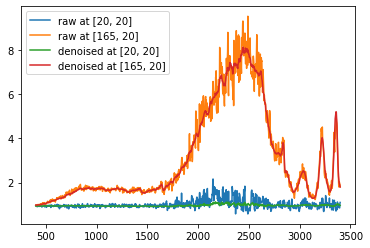

In [ ]:
plt.plot(wn,ratio_selected[point_signal[0],point_signal[1],:], label=f'raw at {point_signal}')
#plt.plot(wn, reconstructed_reshaped[point_signal[0],point_signal[1],:],label =f'svd at {point_signal}')
plt.plot(wn,ratio_selected[point_noise[0],point_noise[1],:], label=f'raw at {point_noise}')
#plt.plot(wn, reconstructed_reshaped[point_noise[0],point_noise[1],:],label =f'svd at {point_noise}')
plt.plot(wn, denoised[point_signal[0],point_signal[1],:], label=f'denoised at {point_signal}')
plt.plot(wn, denoised[point_noise[0],point_noise[1],:], label=f'denoised at {point_noise}')
plt.legend()

#plt.ylim([0.8,1.2])

(400.0, 2000.0)

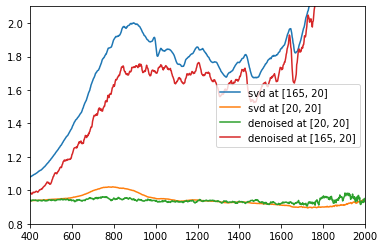

In [ ]:
plt.plot(wn, reconstructed_reshaped[point_noise[0],point_noise[1],:],label =f'svd at {point_noise}')
plt.plot(wn, reconstructed_reshaped[point_signal[0],point_signal[1],:],label =f'svd at {point_signal}')
plt.plot(wn, denoised[point_signal[0],point_signal[1],:], label=f'denoised at {point_signal}')
plt.plot(wn, denoised[point_noise[0],point_noise[1],:], label=f'denoised at {point_noise}')
plt.legend()
plt.ylim([.8,2.1])
plt.xlim([400,2000])

In [18]:
kkrelation = KramersKronig(cars_amp_offset=0.0, nrb_amp_offset=0.0, conjugate=False,
                 phase_offset=0.0, norm_to_nrb=True, pad_factor=1, 
                 rng=None, n_edge=30, axis=-1, bad_value=1e-8, min_value=None)
bg = np.ones(ratio_selected.shape)
cri_denoised = reconstructed_reshaped
ph_denoised = kkrelation.calculate(cri_denoised,bg)

Text(0.5, 1.0, 'KK on SVD denoised data at pixel [20, 20]')

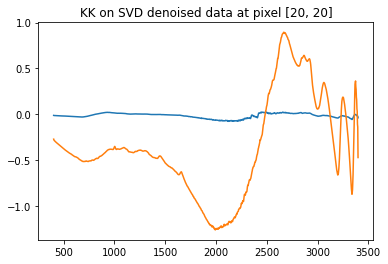

In [19]:
plt.plot(wn,np.imag(ph_denoised[point_signal[0],point_signal[1],:]), label=f'denoised at signal{point_signal}')
plt.plot(wn,np.imag(ph_denoised[point_noise[0],point_noise[1],:]), label=f'denoised at background{point_noise}')
plt.title('KK on SVD denoised data at pixel {}'.format(point_signal))

Text(0.5, 1.0, 'KK on raw data at pixel [20, 20]')

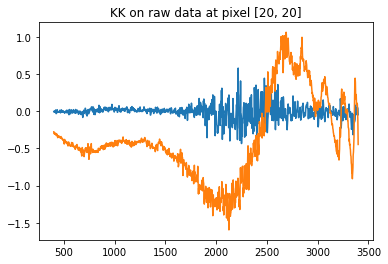

In [20]:
cri_raw = ratio_selected
ph_raw = kkrelation.calculate(cri_raw,bg)
plt.plot(wn,np.imag(ph_raw[point_signal[0],point_signal[1],:]), label=f'raw at {point_signal}')
plt.plot(wn,np.imag(ph_raw[point_noise[0],point_noise[1],:]), label=f'raw at {point_noise}')
plt.title(f'KK on raw data at pixel {point_signal}')

Text(0.5, 1.0, 'KK on denoised data at pixel [20, 20]')

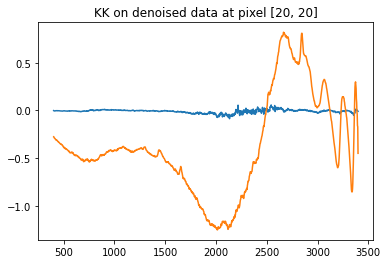

In [21]:
cri_n2n = denoised
ph_n2n = kkrelation.calculate(cri_n2n,bg)
plt.plot(wn,np.imag(ph_n2n[point_signal[0],point_signal[1],:]), label=f'denoised at {point_signal}')
plt.plot(wn,np.imag(ph_n2n[point_noise[0],point_noise[1],:]), label=f'denoised at {point_noise}')
plt.title(f'KK on denoised data at pixel {point_signal}')

In [22]:
pec = PhaseErrCorrectALS(smoothness_param=1, asym_param=5e-5,
                 redux=5, order=2, rng=None, fix_end_points=False,
                 fix_rng=None, fix_const=1, max_iter=100, min_diff=1e-6,
                 verbose=False)

In [23]:
ph_denoised_corrected = pec.calculate(ph_denoised)


Text(0.5, 1.0, 'KK + Phase Error Correction on SVD denoised data at pixel [20, 20]')

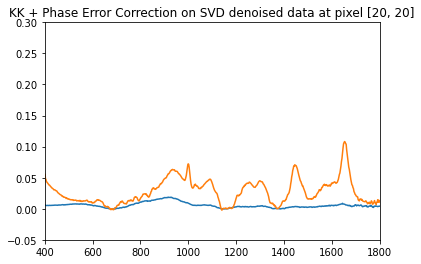

In [24]:
plt.plot(wn,np.imag(ph_denoised_corrected[point_signal[0],point_signal[1],:]), label=f'denoised at signal{point_signal}')
plt.plot(wn,np.imag(ph_denoised_corrected[point_noise[0],point_noise[1],:]), label=f'denoised at background{point_noise}')
plt.xlim([400,1800])
plt.ylim([-0.05,0.3])
plt.title(f'KK + Phase Error Correction on SVD denoised data at pixel {point_signal}')

In [25]:
ph_raw_corrected = pec.calculate(ph_raw)
#ph_raw_corrected = pec.calculate(ph_raw)


Text(0.5, 1.0, 'KK + Phase Error Correction on raw data at pixel [20, 20]')

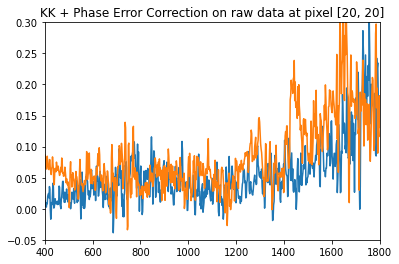

In [26]:
plt.plot(wn,np.imag(ph_raw_corrected[point_signal[0],point_signal[1],:]), label=f'corrected at signal{point_signal}')
plt.plot(wn,np.imag(ph_raw_corrected[point_noise[0],point_noise[1],:]), label=f'corrected at background{point_noise}')
plt.xlim([400,1800])
plt.ylim([-0.05,0.3])

plt.title(f'KK + Phase Error Correction on raw data at pixel {point_signal}')

In [27]:
ph_n2n_corrected = pec.calculate(ph_n2n)


Text(0.5, 1.0, 'KK + Phase Error Correction on n2n data at pixel [20, 20]')

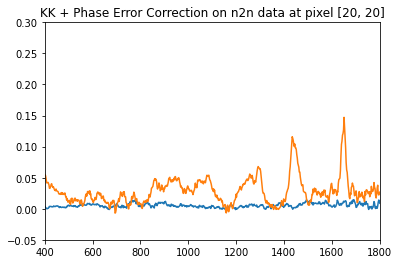

In [ ]:
plt.plot(wn,np.imag(ph_n2n_corrected[point_signal[0],point_signal[1],:]), label=f'corrected at signal{point_signal}')
plt.plot(wn,np.imag(ph_n2n_corrected[point_noise[0],point_noise[1],:]), label=f'corrected at background{point_noise}')
plt.xlim([400,1800])
plt.ylim([-0.05,0.3])
plt.title(f'KK + Phase Error Correction on n2n data at pixel {point_signal}')

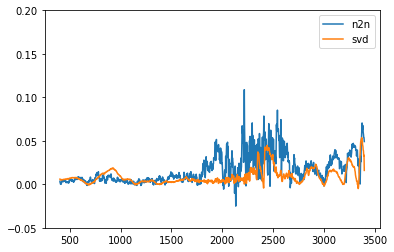

In [32]:
plt.plot(wn,np.imag(ph_n2n_corrected[point_signal[0],point_signal[1],:]), label=f'n2n')
plt.plot(wn,np.imag(ph_denoised_corrected[point_signal[0],point_signal[1],:]), label=f'svd')
#plt.xlim([2800,3400])
plt.ylim([-0.05,0.2])
plt.legend()

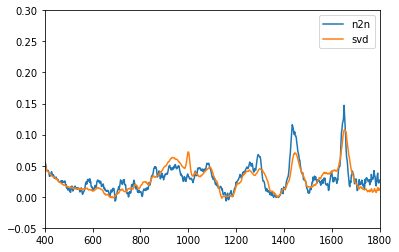

In [39]:
plt.plot(wn,np.imag(ph_n2n_corrected[point_noise[0],point_noise[1],:]), label=f'n2n')
plt.plot(wn,np.imag(ph_denoised_corrected[point_noise[0],point_noise[1],:]), label=f'svd')
plt.xlim([400,1800])
plt.ylim([-0.05,0.3])
plt.legend()

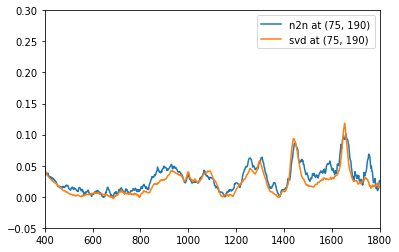

Text(0.5, 1.0, 'KK + Phase Error Correction on SVD denoised data')

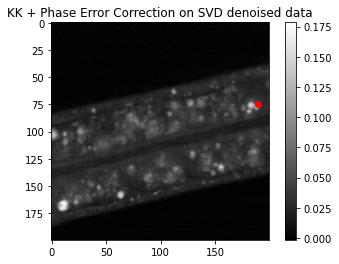

In [70]:
ranx = np.random.randint(0, denoised.shape[0])
rany = np.random.randint(0, denoised.shape[1])
ranx =75
rany = 190
plt.plot(wn,np.imag(ph_n2n_corrected[ranx,rany,:]), label=f'n2n at {ranx,rany}')
plt.plot(wn,np.imag(ph_denoised_corrected[ranx,rany,:]), label=f'svd at {ranx,rany}')
plt.xlim([400,1800])
plt.ylim([-0.05,0.3])
plt.legend()    
plt.show()
plt.imshow(np.imag(ph_denoised_corrected[:,:,signature_index]), cmap='gray')
plt.plot(rany, ranx, 'ro')  # Note the order (x, y)
plt.colorbar()
plt.title('KK + Phase Error Correction on SVD denoised data')

(400.0, 1200.0)

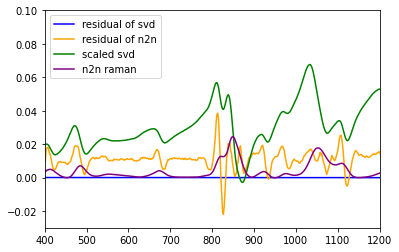

In [174]:
raw_avg_spectrum = np.mean(raw, axis=(0, 1))
svd_avg_spectrum = np.mean(reconstructed_reshaped, axis=(0, 1))
n2n_avg_spectrum = np.mean(denoised, axis=(0, 1))
n2n_avg_raman = np.mean(np.imag(ph_n2n_corrected), axis=(0, 1))
plt.plot(wn,raw_avg_spectrum-svd_avg_spectrum, label=f'residual of svd',color='blue')
plt.plot(wn,raw_avg_spectrum-n2n_avg_spectrum, label=f'residual of n2n',color='orange')
plt.plot(wn,(svd_avg_spectrum-1)/10, label=f'scaled svd',color='green')
plt.plot(wn,n2n_avg_raman/10, label=f'n2n raman',color='purple')
plt.legend()
plt.ylim([-0.03,0.1])
plt.xlim([400,1200])

In [176]:
print(wn.size)

1345
